## FASE 4: Interpolación y Suavizado mediante Splines Cúbicos

En esta fase, aplicamos la interpolación por **Splines Cúbicos** para obtener una función continua $S(t)$ que represente fielmente la trayectoria del precio.

**Fundamento Matemático:**
A diferencia de los polinomios globales, los Splines cúbicos se definen por tramos, garantizando la continuidad de la función y de sus dos primeras derivadas ($S'(t)$ y $S''(t)$). Esto evita las oscilaciones artificiales (Fenómeno de Runge) y proporciona una curva suave que es analíticamente derivable.

**Ventajas Técnicas:**
1. **Fidelidad de Datos:** La curva intercepta todos los puntos observados de la serie temporal.
2. **Derivabilidad:** La suavidad de la curva permite el cálculo preciso de la tasa de variación del precio.
3. **Validación:** Se comparará esta interpolación con el túnel de volatilidad para confirmar que el suavizado no distorsiona la realidad del mercado.

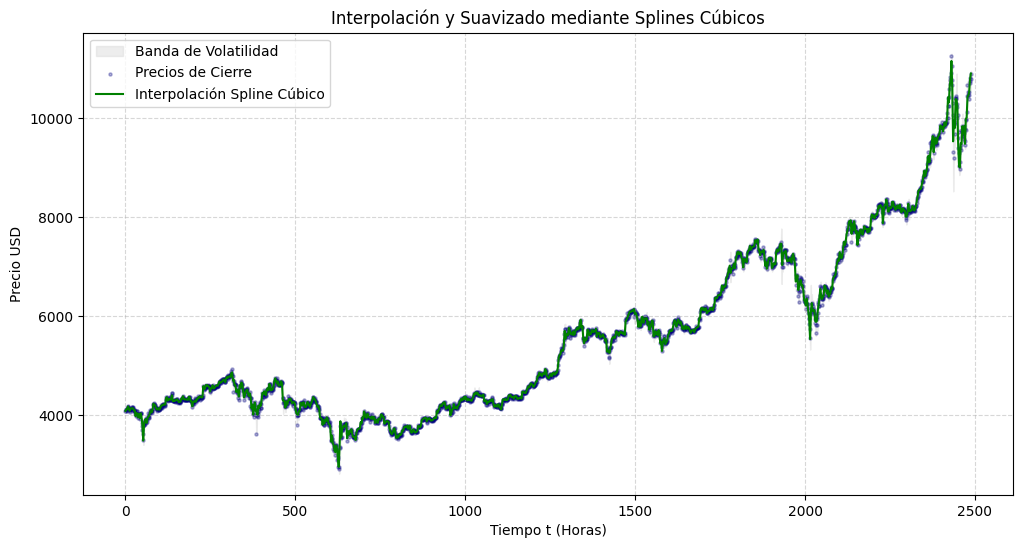

--- RESULTADOS DE LA FASE 4 ---
Se ha generado una función S(t) continua y derivable en todo el intervalo.
Número de nodos de interpolación: 2489


In [ ]:
#@title Suavizado de Curva (Splines Cúbicos)
from scipy.interpolate import CubicSpline
import numpy as np
import matplotlib.pyplot as plt

# --- 1. PREPARACIÓN DE DATOS ---
t_datos = df_analisis['t'].values
y_datos = df_analisis['close_price'].values

# --- 2. CÁLCULO DEL SPLINE CÚBICO ---
# Generamos la función spline interpolante
spline = CubicSpline(t_datos, y_datos)

# Creamos un eje t más denso para que la curva se vea suave al graficar
t_suave = np.linspace(t_datos.min(), t_datos.max(), 1000)
y_spline = spline(t_suave)

# --- 3. VISUALIZACIÓN COMPARATIVA ---
plt.figure(figsize=(12, 6))

# Banda de Volatilidad (Fase 2)
plt.fill_between(t_datos, df_analisis['low_price'], df_analisis['high_price'],
                 color='lightgray', alpha=0.4, label='Banda de Volatilidad')

# Datos Reales
plt.scatter(t_datos, y_datos, color='navy', s=5, alpha=0.3, label='Precios de Cierre')

# Spline Cúbico (Fase 4)
plt.plot(t_suave, y_spline, color='green', linewidth=1.5, label='Interpolación Spline Cúbico')

# Formato Técnico
plt.title('Interpolación y Suavizado mediante Splines Cúbicos')
plt.xlabel('Tiempo t (Horas)')
plt.ylabel('Precio USD')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# --- 4. REPORTE DE CONTINUIDAD ---
print("--- RESULTADOS DE LA FASE 4 ---")
print("Se ha generado una función S(t) continua y derivable en todo el intervalo.")
print(f"Número de nodos de interpolación: {len(t_datos)}")